In [1]:
import json
import os
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)

KAGGLE_USERNAME = "YOUR_KAGGLE_USERNAME"
KAGGLE_KEY = "YOUR_KAGGLE_KEY"

kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

!chmod 600 /root/.kaggle/kaggle.json
print("✅ Ready!")

Mounted at /content/drive
✅ Ready!


In [2]:
# Download UNSW-NB15 dataset
!kaggle datasets download -d mrwellsdavid/unsw-nb15 -p /content/unsw/
!unzip -q /content/unsw/unsw-nb15.zip -d /content/unsw/

print("Download complete!")
print(os.listdir('/content/unsw/'))

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:00<00:00, 231MB/s]

Download complete!
['UNSW-NB15_3.csv', 'UNSW-NB15_4.csv', 'unsw-nb15.zip', 'NUSW-NB15_features.csv', 'UNSW_NB15_testing-set.csv', 'UNSW-NB15_2.csv', 'UNSW_NB15_training-set.csv', 'UNSW-NB15_1.csv', 'UNSW-NB15_LIST_EVENTS.csv']


In [3]:
# Load the pre-split datasets
df_train = pd.read_csv('/content/unsw/UNSW_NB15_training-set.csv')
df_test = pd.read_csv('/content/unsw/UNSW_NB15_testing-set.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nColumns: {list(df_train.columns)}")
print(f"\nLabel distribution (Train):")
print(df_train['label'].value_counts())

Train shape: (82332, 45)
Test shape: (175341, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Label distribution (Train):
label
1    45332
0    37000
Name: count, dtype: int64


In [4]:
# Explore the dataset
print("=== Data Types ===")
print(df_train.dtypes.value_counts())

print("\n=== Attack Categories ===")
print(df_train['attack_cat'].value_counts())

print("\n=== Missing Values ===")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

print("\n=== Basic Statistics ===")
print(df_train.describe())

=== Data Types ===
int64      30
float64    11
object      4
Name: count, dtype: int64

=== Attack Categories ===
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

=== Missing Values ===
Series([], dtype: int64)

=== Basic Statistics ===
                 id           dur         spkts         dpkts        sbytes  \
count  82332.000000  82332.000000  82332.000000  82332.000000  8.233200e+04   
mean   41166.500000      1.006756     18.666472     17.545936  7.993908e+03   
std    23767.345519      4.710444    133.916353    115.574086  1.716423e+05   
min        1.000000      0.000000      1.000000      0.000000  2.400000e+01   
25%    20583.750000      0.000008      2.000000      0.000000  1.140000e+02   
50%    41166.500000      0.014138      6.000000      2.00000

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Combine train and test for processing
df = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total records: {df.shape[0]:,}")

# Drop irrelevant columns
df = df.drop(columns=['id', 'attack_cat'])

# Encode categorical columns
cat_cols = ['proto', 'service', 'state']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded {col}: {df[col].nunique()} unique values")

print(f"\nFinal shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Total records: 257,673
Encoded proto: 133 unique values
Encoded service: 13 unique values
Encoded state: 11 unique values

Final shape: (257673, 43)

Label distribution:
label
1    164673
0     93000
Name: count, dtype: int64


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Split features and labels
X = df.drop(columns=['label'])
y = df['label']

# Train/Val/Test split — 80/10/10
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,}")
print(f"Val:   {X_val.shape[0]:,}")
print(f"Test:  {X_test.shape[0]:,}")
print("✅ Ready for modeling!")

Train: 206,138
Val:   25,767
Test:  25,768
✅ Ready for modeling!


In [7]:
# Calculate scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost with same hyperparameters as CICIDS2017
print("\nTraining XGBoost on UNSW-NB15...")
start_time = time.time()

xgb_unsw = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=1
)

xgb_unsw.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=10
)

train_time = time.time() - start_time
print(f"\n✅ Training completed in {train_time:.1f} seconds!")

scale_pos_weight: 0.56

Training XGBoost on UNSW-NB15...
[0]	validation_0-auc:0.97954
[10]	validation_0-auc:0.98716
[20]	validation_0-auc:0.98899
[30]	validation_0-auc:0.99003
[40]	validation_0-auc:0.99056
[50]	validation_0-auc:0.99084
[60]	validation_0-auc:0.99114
[70]	validation_0-auc:0.99115
[80]	validation_0-auc:0.99134
[90]	validation_0-auc:0.99143
[100]	validation_0-auc:0.99154
[110]	validation_0-auc:0.99162
[120]	validation_0-auc:0.99173
[130]	validation_0-auc:0.99176
[140]	validation_0-auc:0.99180
[150]	validation_0-auc:0.99189
[160]	validation_0-auc:0.99192
[170]	validation_0-auc:0.99198
[180]	validation_0-auc:0.99198
[190]	validation_0-auc:0.99196
[199]	validation_0-auc:0.99202

✅ Training completed in 9.7 seconds!


=== XGBoost — UNSW-NB15 Test Set Evaluation ===

              precision    recall  f1-score   support

      Normal       0.90      0.97      0.93      9300
      Attack       0.98      0.94      0.96     16468

    accuracy                           0.95     25768
   macro avg       0.94      0.95      0.95     25768
weighted avg       0.95      0.95      0.95     25768

ROC-AUC Score: 0.9923


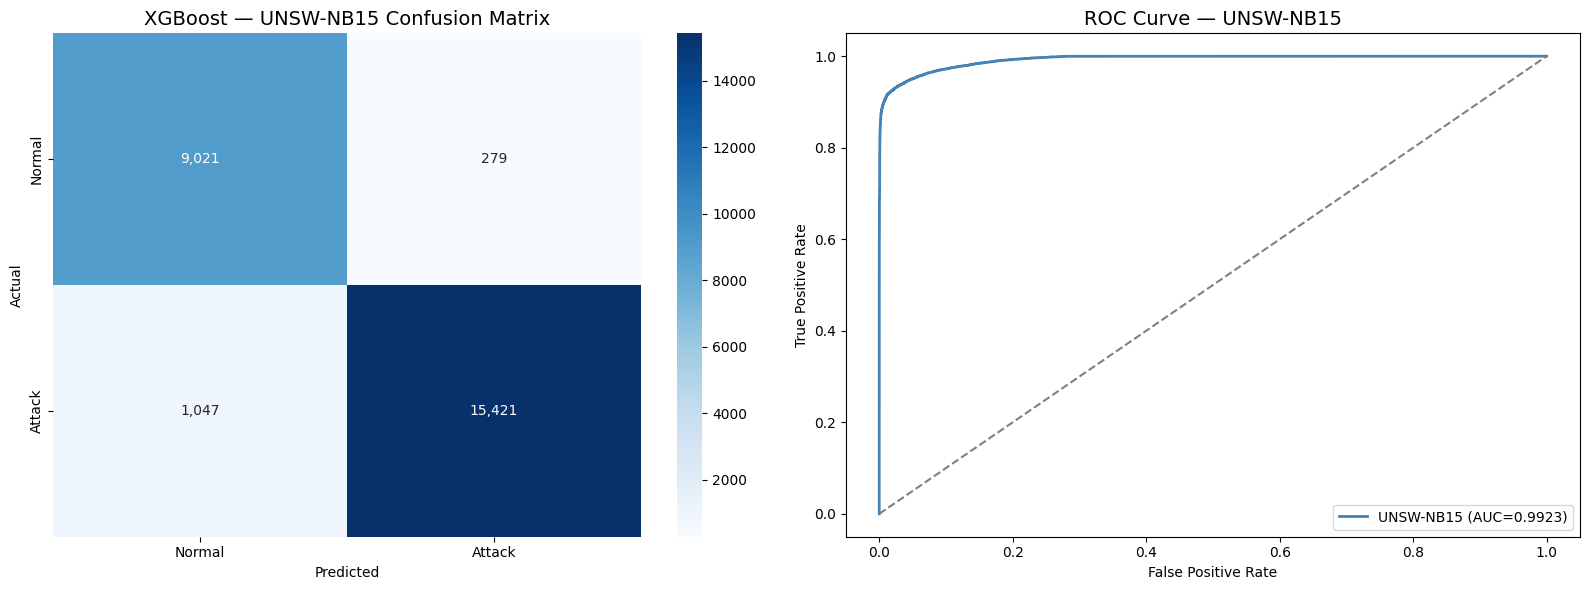

✅ Evaluation complete!


In [8]:
# Evaluate on test set
print("=== XGBoost — UNSW-NB15 Test Set Evaluation ===\n")

y_pred = xgb_unsw.predict(X_test_scaled)
y_pred_proba = xgb_unsw.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred,
                            target_names=['Normal', 'Attack']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            ax=axes[0])
axes[0].set_title('XGBoost — UNSW-NB15 Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'UNSW-NB15 (AUC={auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — UNSW-NB15', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()
print("✅ Evaluation complete!")

In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("Starting Randomized Search on UNSW-NB15...")
print("Testing 10 random combinations × 3-Fold CV = 30 fits\n")

xgb_search = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)

random_search = RandomizedSearchCV(
    xgb_search,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best parameters found:")
print(random_search.best_params_)
print(f"\nBest F1 Score: {random_search.best_score_:.4f}")

Starting Randomized Search on UNSW-NB15...
Testing 10 random combinations × 3-Fold CV = 30 fits

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best parameters found:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.3, 'colsample_bytree': 0.8}

Best F1 Score: 0.9571


Training Final Tuned XGBoost on UNSW-NB15...
[0]	validation_0-auc:0.97954
[10]	validation_0-auc:0.98716
[20]	validation_0-auc:0.98899
[30]	validation_0-auc:0.99003
[40]	validation_0-auc:0.99056
[50]	validation_0-auc:0.99084
[60]	validation_0-auc:0.99114
[70]	validation_0-auc:0.99115
[80]	validation_0-auc:0.99134
[90]	validation_0-auc:0.99143
[100]	validation_0-auc:0.99154
[110]	validation_0-auc:0.99162
[120]	validation_0-auc:0.99173
[130]	validation_0-auc:0.99176
[140]	validation_0-auc:0.99180
[150]	validation_0-auc:0.99189
[160]	validation_0-auc:0.99192
[170]	validation_0-auc:0.99198
[180]	validation_0-auc:0.99198
[190]	validation_0-auc:0.99196
[199]	validation_0-auc:0.99202

✅ Training completed in 19.8 seconds!

=== Final Tuned XGBoost — UNSW-NB15 Test Set ===

              precision    recall  f1-score   support

      Normal       0.90      0.97      0.93      9300
      Attack       0.98      0.94      0.96     16468

    accuracy                           0.95     25768
   macr

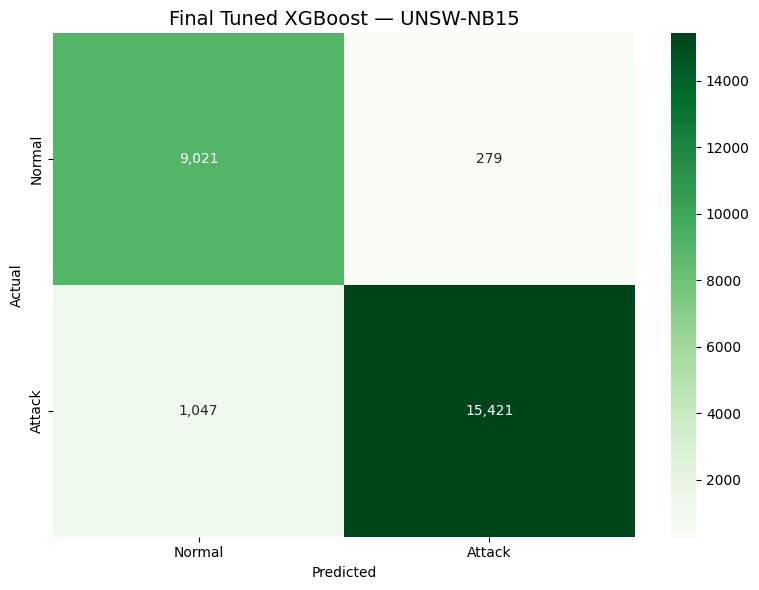

✅ Done!


In [10]:
# Train final tuned model
print("Training Final Tuned XGBoost on UNSW-NB15...")
start_time = time.time()

xgb_unsw_final = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.3,
    subsample=1.0,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=1
)

xgb_unsw_final.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=10
)

train_time = time.time() - start_time
print(f"\n✅ Training completed in {train_time:.1f} seconds!")

# Evaluate on test set
print("\n=== Final Tuned XGBoost — UNSW-NB15 Test Set ===\n")

y_pred_final = xgb_unsw_final.predict(X_test_scaled)
y_pred_proba_final = xgb_unsw_final.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_final,
                            target_names=['Normal', 'Attack']))

auc_final = roc_auc_score(y_test, y_pred_proba_final)
print(f"ROC-AUC Score: {auc_final:.4f}")

# Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt=',', cmap='Greens',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Final Tuned XGBoost — UNSW-NB15', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("✅ Done!")